In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.19MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.8MB/s]


In [6]:
class BaseModel(nn.Module):
    def __init__(self, num_features=784, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(num_features, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten: [Batch, 1, 28, 28] -> [Batch, 784]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [7]:
def train_model(use_smoothing=False, alpha=0.1):
    model = BaseModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # Configure Loss function
    if use_smoothing:
        criterion = nn.CrossEntropyLoss(label_smoothing=alpha)
    else:
        criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # Validation evaluation
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                preds = outputs.argmax(dim=-1)
                correct += (preds == labels).sum().item()

        epoch_val_loss = val_loss / len(test_loader.dataset)
        epoch_val_acc = (correct / len(test_loader.dataset)) * 100

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

    # Gather structural final confidences on the test set for calibration graphs
    confidences = []
    model.eval()
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            logits = model(images)
            probs = F.softmax(logits, dim=-1)
            max_probs, _ = torch.max(probs, dim=-1)
            confidences.extend(max_probs.cpu().numpy())

    return history, confidences

In [8]:
print("Running Normal Training Experiment...")
normal_hist, normal_conf = train_model(use_smoothing=False)

print("Running Label Smoothing Experiment (alpha=0.1)...")
smooth_hist, smooth_conf = train_model(use_smoothing=True, alpha=0.1)

Running Normal Training Experiment...
Running Label Smoothing Experiment (alpha=0.1)...


In [9]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

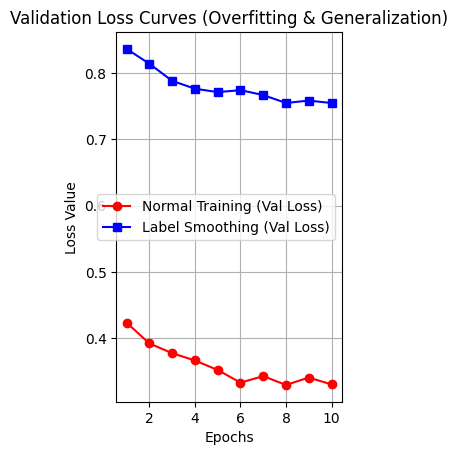

In [10]:
plt.subplot(1, 2, 1)
plt.plot(epochs_range, normal_hist['val_loss'], 'r-o', label='Normal Training (Val Loss)')
plt.plot(epochs_range, smooth_hist['val_loss'], 'b-s', label='Label Smoothing (Val Loss)')
plt.title('Validation Loss Curves (Overfitting & Generalization)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True)
plt.legend()

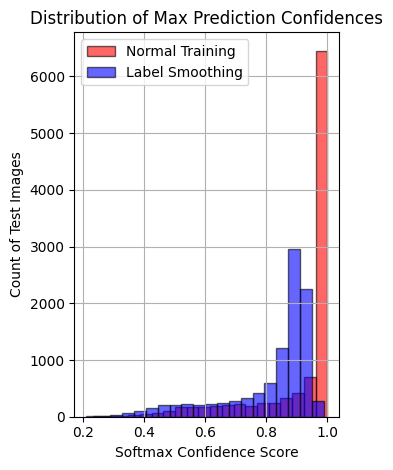

In [11]:
plt.subplot(1, 2, 2)
plt.hist(normal_conf, bins=20, alpha=0.6, color='red', label='Normal Training', edgecolor='black')
plt.hist(smooth_conf, bins=20, alpha=0.6, color='blue', label='Label Smoothing', edgecolor='black')
plt.title('Distribution of Max Prediction Confidences')
plt.xlabel('Softmax Confidence Score')
plt.ylabel('Count of Test Images')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()